In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import time
import open3d as o3d
import utils 

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [15]:
# TODO ################# Change the values based on how much of the azimuth angles you want to see and the resolution ##################
# Define field of view in degrees that you want to process in theta, phi and range bins
def beamform_2d(beat_freq_data, phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_ant_pos, z_ant_pos, r_idxs, radar_params):
    """
    Performs 2D beamforming along the azimuth (horizontal) dimension, this results in a bird eye view image.
    - beat_freq_data: beat data AKA the range FFT (size: num_x_stps * num_z_stps * num TX * num RX, num ADC samples)
    - phi_s: first azimuth angle that you want to start computing 
    - phi_e: last azimuth angle that you want to compute 
    - phi_res: resolution of the azimuth angles you want to compute
    - theta_s: first elevation angle that you want to start computing 
    - theta_e: last elevation angle that you want to compute 
    - theta_res: resolution of the elevation angles you want to compute
    - x_locs: x coordinate of antenna locations
    - z_locs: z coordinate of antenna locations
    - r_idx: range bins to calculate 
    - radar_parms: radar_params if needed 

    Returns:
    - sph_pwr: beamformed result (size: n_phi, n_theta, n_range)
    - phi: array of azimuth angles 
    - theta: array of elevation angles 
    """
    # Convert angles to radians
    phi = np.radians(np.arange(phi_s, phi_e, phi_res))  # Azimuth angles (φ)
    theta = np.radians(np.arange(theta_s, theta_e, theta_res))  # Elevation angles (θ)

    num_phi = len(phi)
    num_theta = len(theta)
    num_range = len(r_idxs)

    lm = radar_params['lm']  # Wavelength (λ)

    # Initialize beamformed output
    sph_pwr = np.zeros((num_phi, num_theta, num_range), dtype=np.complex64)

    # Iterate over azimuth (φ) and elevation (θ)
    for p_idx, p in enumerate(phi):
        for t_idx, t in enumerate(theta):

            angles = x_ant_pos * np.sin(t) * np.cos(p) +  z_ant_pos * np.cos(t)

            phase_shifts = np.exp((1j * 2 * np.pi / lm) * angles)
       
            beamformed_signal = beat_freq_data * phase_shifts[:, :, np.newaxis]
        
            sph_pwr[p_idx, t_idx, :] = np.abs(np.sum(np.sum(beamformed_signal, axis=0), axis=0))

    return sph_pwr, phi, theta

Load data.

In [16]:
data_path = r"C:\\Users\\kresl\\Documents\\COM-304\\record\\rdc_usedj_thomas_superposed"
static_data_path = r"C:\\Users\\kresl\\Documents\\COM-304\\record\\rdc_vide.mat"

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)
radar_params_static, raw_data_static = utils.load_raw_data(static_data_path)
print(raw_data.shape)
print(raw_data_static.shape)

(12, 500, 512)
(12, 499, 512)


Defining antenna positions. 

In [26]:
x_ant_pos1, z_ant_pos1, x_ant = utils.get_ant_pos_2d(radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['num_rx']) # this returns x position of rx, z positions of rx and tx, and x position of tx
x_ant_pos, z_ant_pos = utils.get_ant_static_2d(radar_params['num_frames'], radar_params['num_tx'], radar_params['num_rx'], radar_params['adc_samples'])
#print(x_ant_pos.shape, z_ant_pos.shape)
print(x_ant_pos, x_ant_pos1)

[[0.        ]
 [0.00194805]
 [0.0038961 ]
 [0.00584416]
 [0.0038961 ]
 [0.00584416]
 [0.00779221]
 [0.00974026]
 [0.00779221]
 [0.00974026]
 [0.01168831]
 [0.01363636]] [[ 0.00000000e+00]
 [-1.94805195e-03]
 [-3.89610390e-03]
 [-5.84415584e-03]
 [ 3.89610390e-03]
 [ 1.94805195e-03]
 [-2.16840434e-19]
 [-1.94805195e-03]
 [ 7.79220779e-03]
 [ 5.84415584e-03]
 [ 3.89610390e-03]
 [ 1.94805195e-03]]


Process raw data for BF algorthim (use all samples now).

In [18]:
# TODO: reshape raw_data and process beat frequency
# Process raw data for BF algorithm (use all samples now)
    
beat_freq = np.fft.fft(raw_data, axis=-1)  # Perform FFT along the last axis (ADC samples)
static_beat_freq = np.fft.fft(raw_data_static)

#beat_freq = np.fft.fftshift(beat_freq, axes=-1)  # Shift the zero frequency to the center

beat_freq_super = beat_freq[:, 0:499, :] - static_beat_freq[:, :, :]

print(beat_freq_super.shape)

(12, 499, 512)


Define the angles and range bins to run, and run the BF algo.

In [19]:
# define the azimuth angles (horizontal FOV) that we want to look at 
c = 3e8  # Speed of light in m/s
slope = radar_params['slope']  # Given in radar_params
sample_rate = radar_params['sample_rate']  # Sampling rate from radar_params

num_samples = radar_params['num_samples']
r_idxs = np.arange(0, 140, 1) # Change to distance rather than range bins 
phi_s, phi_e = 0, 180 
phi_res = 1
theta_s, theta_e = 70,110 
theta_res = 1

# Run your algorithm here
# TODO: input arguments that you choose
bf_output1, phi, theta = beamform_2d(beat_freq_super[:, 0:499, r_idxs], phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_ant_pos, z_ant_pos, r_idxs, radar_params)
print(bf_output1.shape)

(180, 40, 140)


Here you should plot the outputs from beamforming.

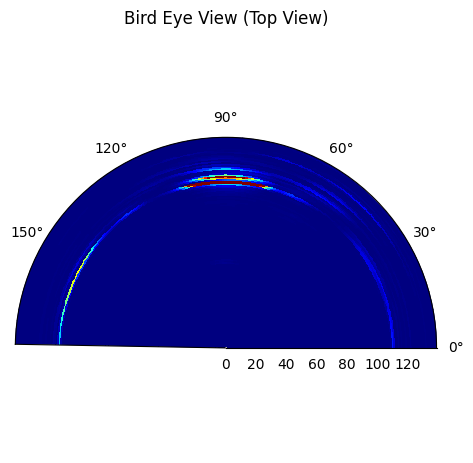

In [20]:
# Plot the output from 2D Beamforming (You can change this as you see fit)
fig = plt.figure(figsize=(25, 7))

#to_plot = np.sum(abs(bf_output1),axis=-1)
#to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
#to_plot = to_plot**2
#ax0 = fig.add_subplot(141)
#utils.plot_2d_polar_heatmap(ax0, to_plot, phi, theta, vmin=0, vmax=0.1)
#ax0.title.set_text('Front View')

to_plot = np.sum(abs(bf_output1),axis=1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot**2
ax1 = fig.add_subplot(142,projection = 'polar')
utils.plot_2d_heatmap(ax1, to_plot, phi, r_idxs, vmin=0, vmax=0.1)
ax1.title.set_text('Bird Eye View (Top View)')

#to_plot = np.sum(abs(bf_output1),axis=0)
#to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
#to_plot = to_plot**2
#ax2 = fig.add_subplot(143)
#utils.plot_2d_heatmap(ax2, to_plot, theta, r_idxs, vmin=0, vmax=0.1)
#ax2.title.set_text('Side View')

#ax3 = fig.add_subplot(144, projection="3d")
#to_plot = np.transpose(abs(bf_output1), (2,0,1))**2
#to_plot = bf_output1
#to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
#to_plot = to_plot**2
#utils.plot_3d_polar_heatmap(ax3, to_plot, phi, theta, r_idxs, 0.1)
#ax3.title.set_text('Point Clouds')

#plt.tight_layout()
plt.show()

In [16]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from tqdm import tqdm
import utils

# === File Paths ===
data_path = r"/home/tim/Documents/EPFL/COM-304-Radars/record/rdc_usedj_marche.mat"
static_data_path = r"/home/tim/Documents/EPFL/COM-304-Radars/record/rdc_vide.mat"

# === Load dynamic signal ===
radar_params, raw_data = utils.load_raw_data(data_path)  # (12, num_frames, 512)

# === Load static noise frame ===
_, raw_data_static = utils.load_raw_data(static_data_path)  # (12, 1, 512) or (12, 512)
#if raw_data_static.ndim == 2:
#    raw_data_static = raw_data_static[:, np.newaxis, :]  # (12, 1, 512)

# Pad static data if needed
if raw_data_static.shape[1] < radar_params['num_frames']:
    num_missing = radar_params['num_frames'] - raw_data_static.shape[1]
    last_frame = raw_data_static[:, -1:, :]  # shape: (12, 1, 512)
    padding = np.repeat(last_frame, num_missing, axis=1)  # (12, missing_frames, 512)
    raw_data_static = np.concatenate([raw_data_static, padding], axis=1)  # (12, 500, 512)


# === FFT both ===
beat_freq = np.fft.fft(raw_data, axis=-1)  # (12, num_frames, 512)
static_beat_freq = np.fft.fft(raw_data_static, axis=-1)  # (12, 1, 512)
beat_freq_super = beat_freq[:, :, :] - static_beat_freq  # broadcasting over frames

# === Antenna positions ===
#x_ant_pos, z_ant_pos = utils.get_ant_static_2d(
#    radar_params['num_frames'],
#    radar_params['num_tx'],
#    radar_params['num_rx'],
#    radar_params['adc_samples']
#)

x_ant_pos, z_ant_pos, _ = utils.get_ant_pos_2d(radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['num_rx'])

# === Beamforming parameters ===
r_idxs = np.arange(0, 140)
phi_s, phi_e, phi_res = 0, 180, 1
theta_s, theta_e, theta_res = 70, 110, 1
phi = np.radians(np.arange(phi_s, phi_e, phi_res))
theta = np.radians(np.arange(theta_s, theta_e, theta_res))
num_frames = radar_params['num_frames']

# === Precompute Beamforming ===
print("⚙️ Precomputing beamformed frames with noise removal...")
bf_frames = []
for i in tqdm(range(num_frames)):
    frame = beat_freq_super[:, i, :][:, np.newaxis, :]  # (12, 1, 512)

    bf, _, _ = beamform_2d(
        frame[:, :, r_idxs],
        phi_s, phi_e, phi_res,
        theta_s, theta_e, theta_res,
        x_ant_pos, z_ant_pos,
        r_idxs, radar_params
    )

    bf = np.abs(bf)
    bf /= np.max(bf)
    bf = bf ** 2
    bf_frames.append(np.sum(bf, axis=1))  # (phi, range)

# === Create animation ===
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='polar')

def update(frame_idx):
    ax.clear()
    to_plot = bf_frames[frame_idx]
    utils.plot_2d_heatmap(ax, to_plot, phi, r_idxs, vmin=0, vmax=0.1)
    ax.set_title(f'Top View Frame {frame_idx+1}/{num_frames}', va='bottom')
    return ax.collections

ani = animation.FuncAnimation(fig, update, frames=len(bf_frames), interval=50, blit=False)
ani.save("top_view_video.gif", writer='pillow', fps=20)
plt.close(fig)
print("✅ Saved: top_view_video.gif")


⚙️ Precomputing beamformed frames with noise removal...


100%|██████████| 500/500 [02:17<00:00,  3.63it/s]


✅ Saved: top_view_video.gif
